<a href="https://colab.research.google.com/github/sehgalswapnil760-hue/first-python-project/blob/main/CalibModelLowCostSensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

In [9]:
from google.colab import files

print("Sensor CSV file upload karo:")
uploaded_sensor = files.upload()
sensor_filename = list(uploaded_sensor.keys())[0]

Sensor CSV file upload karo:


Saving Sensor_File.csv to Sensor_File.csv


In [10]:
from google.colab import files

print("BAM reference CSV file upload karo:")
uploaded_bam = files.upload()
bam_filename = list(uploaded_bam.keys())[0]

BAM reference CSV file upload karo:


Saving BAM_File.csv to BAM_File.csv


In [15]:
df_sensor_raw = pd.read_csv(sensor_filename)
df_bam_raw = pd.read_csv(bam_filename)

print("Sensor file ke columns:", df_sensor_raw.columns.tolist())
display(df_sensor_raw.head())

print("\nBAM file ke columns:", df_bam_raw.columns.tolist())
display(df_bam_raw.head())

Sensor file ke columns: ['Timestamp', 'Raw_PM2.5', 'Temperature_C', 'Humidity_percent']


,Timestamp,Raw_PM2.5,Temperature_C,Humidity_percent
0,2018-07-24 06:30:00,49.65,39.39,40.45
1,2018-07-24 07:30:00,33.10,40.79,36.11
2,2018-07-24 08:30:00,35.52,40.92,35.77
3,2018-07-24 09:30:00,27.29,41.73,34.02
4,2018-07-24 10:30:00,33.52,42.30,32.55



BAM file ke columns: ['Timestamp', 'Reference_PM2.5']


,Timestamp,Reference_PM2.5
0,2018-07-24 06:30:00,34.0
1,2018-07-24 07:30:00,18.0
2,2018-07-24 08:30:00,17.0
3,2018-07-24 09:30:00,19.0
4,2018-07-24 10:30:00,18.0


In [20]:
SENSOR_TIME_COL = "Timestamp"
SENSOR_PM_COL = "Raw_PM2.5"
SENSOR_TEMP_COL = "Temperature_C"
SENSOR_RH_COL = "Humidity_percent"

BAM_TIME_COL = "Timestamp"
BAM_PM_COL = "Reference_PM2.5"

In [21]:
df_sensor = df_sensor_raw[[SENSOR_TIME_COL, SENSOR_PM_COL, SENSOR_TEMP_COL, SENSOR_RH_COL]].copy()
df_sensor.columns = ["time", "raw_pm25", "temp", "rh"]
df_sensor["time"] = pd.to_datetime(df_sensor["time"], errors="coerce")
n_bad = df_sensor["time"].isna().sum()
if n_bad:
    print(f"Warning: {n_bad} sensor timestamps parse nahi hue, drop kar diye.")
    df_sensor = df_sensor.dropna(subset=["time"])

df_bam = df_bam_raw[[BAM_TIME_COL, BAM_PM_COL]].copy()
df_bam.columns = ["time", "bam_pm25"]
df_bam["time"] = pd.to_datetime(df_bam["time"], errors="coerce")
n_bad = df_bam["time"].isna().sum()
if n_bad:
    print(f"Warning: {n_bad} BAM timestamps parse nahi hue, drop kar diye.")
    df_bam = df_bam.dropna(subset=["time"])

print("OK")

OK


In [22]:
df_sensor_hourly = df_sensor.set_index("time").resample("1h").mean(numeric_only=True).reset_index()
df_bam_hourly = df_bam.set_index("time").resample("1h").mean(numeric_only=True).reset_index()

df = pd.merge(df_sensor_hourly, df_bam_hourly, on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (21665, 5)


,time,raw_pm25,temp,rh,bam_pm25
0,2018-07-24 06:00:00,49.65,39.39,40.45,34.0
1,2018-07-24 07:00:00,33.10,40.79,36.11,18.0
2,2018-07-24 08:00:00,35.52,40.92,35.77,17.0
3,2018-07-24 09:00:00,27.29,41.73,34.02,19.0
4,2018-07-24 10:00:00,33.52,42.30,32.55,18.0


In [23]:
before = len(df)
df = df.dropna(subset=["raw_pm25", "temp", "rh", "bam_pm25"])
df = df[(df["raw_pm25"] >= 0) & (df["raw_pm25"] < 1000)]
df = df[(df["bam_pm25"] >= 0) & (df["bam_pm25"] < 1000)]
df = df.reset_index(drop=True)

print(f"Cleaning se pehle: {before} rows, baad me: {len(df)} rows")

Cleaning se pehle: 21665 rows, baad me: 15755 rows


In [24]:
def time_split(data):
    n = len(data)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    return data.iloc[:train_end].copy(), data.iloc[train_end:val_end].copy(), data.iloc[val_end:].copy()

df_train, df_val, df_test = time_split(df)

print(f"Train: {df_train['time'].min()} se {df_train['time'].max()}  ({len(df_train)} rows)")
print(f"Val:   {df_val['time'].min()} se {df_val['time'].max()}  ({len(df_val)} rows)")
print(f"Test:  {df_test['time'].min()} se {df_test['time'].max()}  ({len(df_test)} rows)")

Train: 2018-07-24 06:00:00 se 2020-02-08 16:00:00  (11028 rows)
Val:   2020-02-08 17:00:00 se 2020-06-18 21:00:00  (2363 rows)
Test:  2020-06-18 22:00:00 se 2021-01-11 22:00:00  (2364 rows)


In [25]:
cal_features = ["raw_pm25", "temp", "rh"]

X_train_cal, y_train_cal = df_train[cal_features], df_train["bam_pm25"]
X_val_cal, y_val_cal = df_val[cal_features], df_val["bam_pm25"]

lin_model = LinearRegression().fit(X_train_cal, y_train_cal)
rf_cal_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_train_cal, y_train_cal)

def evaluate(y_true, y_pred, label):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f"{label:26s} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:.3f}")
    return rmse, mae, r2

print("Calibration performance (VALIDATION set):")
val_rmse_lin, _, _ = evaluate(y_val_cal, lin_model.predict(X_val_cal), "Linear Regression")
val_rmse_rf, _, _ = evaluate(y_val_cal, rf_cal_model.predict(X_val_cal), "Random Forest")

if val_rmse_rf <= val_rmse_lin:
    cal_model = rf_cal_model
    print("-> Random Forest use ho raha hai calibration ke liye (kam validation RMSE).")
else:
    cal_model = lin_model
    print("-> Linear Regression use ho raha hai calibration ke liye (kam validation RMSE).")

df["calibrated_pm25"] = cal_model.predict(df[cal_features])

Calibration performance (VALIDATION set):
Linear Regression          RMSE= 12.46  MAE= 10.24  R2=0.178
Random Forest              RMSE= 13.72  MAE=  9.33  R2=0.004
-> Linear Regression use ho raha hai calibration ke liye (kam validation RMSE).


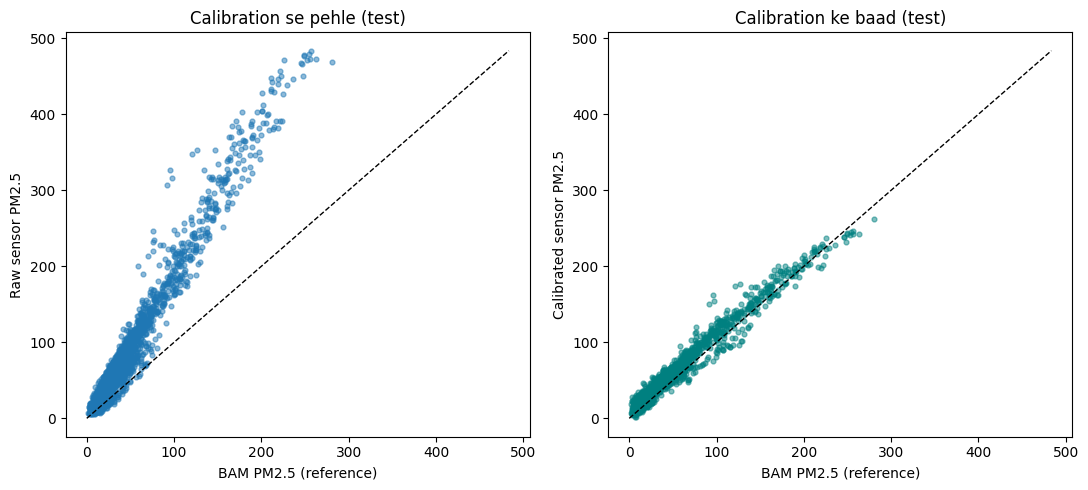

In [26]:
df_test_view = df.loc[df_test.index]

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_test_view["bam_pm25"], df_test_view["raw_pm25"], s=12, alpha=0.5)
lims = [0, max(df_test_view["bam_pm25"].max(), df_test_view["raw_pm25"].max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("BAM PM2.5 (reference)")
plt.ylabel("Raw sensor PM2.5")
plt.title("Calibration se pehle (test)")

plt.subplot(1, 2, 2)
plt.scatter(df_test_view["bam_pm25"], df_test_view["calibrated_pm25"], s=12, alpha=0.5, color="teal")
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("BAM PM2.5 (reference)")
plt.ylabel("Calibrated sensor PM2.5")
plt.title("Calibration ke baad (test)")

plt.tight_layout()
plt.show()

In [27]:
N_LAGS = 24    # EDIT THIS - kitne pichhle ghante dekhne hain
HORIZON = 1    # EDIT THIS - kitne ghante aage predict karna hai

def add_lags(data, col, n_lags, prefix):
    d = data.copy()
    for lag in range(1, n_lags + 1):
        d[f"{prefix}_lag_{lag}"] = d[col].shift(lag)
    return d

feat = df.copy()
feat = add_lags(feat, "raw_pm25", N_LAGS, "raw")
feat = add_lags(feat, "calibrated_pm25", N_LAGS, "cal")
feat["hour"] = feat["time"].dt.hour
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)
feat["target"] = feat["bam_pm25"].shift(-HORIZON)
feat["persistence_pred"] = feat["bam_pm25"]
feat = feat.dropna().reset_index(drop=True)

print(f"Lag features banne ke baad rows: {len(feat)}")
if len(feat) < 50:
    print("WARNING: rows bahut kam hain - N_LAGS chhota karo ya zyada data jama karo.")

raw_feature_cols = [f"raw_lag_{i}" for i in range(1, N_LAGS + 1)] + ["hour_sin", "hour_cos"]
cal_feature_cols = [f"cal_lag_{i}" for i in range(1, N_LAGS + 1)] + ["hour_sin", "hour_cos"]

Lag features banne ke baad rows: 15730


In [28]:
RF_PARAMS = dict(n_estimators=300, max_depth=10, random_state=42)   # EDIT THIS agar tune karna ho

feat_train, feat_val, feat_test = time_split(feat)
print(f"Forecast train/val/test sizes: {len(feat_train)}/{len(feat_val)}/{len(feat_test)}")

model_A = RandomForestRegressor(**RF_PARAMS).fit(feat_train[raw_feature_cols], feat_train["target"])
model_B = RandomForestRegressor(**RF_PARAMS).fit(feat_train[cal_feature_cols], feat_train["target"])

pred_A_test = model_A.predict(feat_test[raw_feature_cols])
pred_B_test = model_B.predict(feat_test[cal_feature_cols])

Forecast train/val/test sizes: 11011/2359/2360


In [29]:
pred_persistence_test = feat_test["persistence_pred"].values
actual_test = feat_test["target"].values

print(f"Forecast performance, TEST set par ({HORIZON} ghanta aage BAM PM2.5 predict karke):")
rmse_pers, mae_pers, r2_pers = evaluate(actual_test, pred_persistence_test, "Persistence baseline")
rmse_A, mae_A, r2_A = evaluate(actual_test, pred_A_test, "Model A (raw input)")
rmse_B, mae_B, r2_B = evaluate(actual_test, pred_B_test, "Model B (calibrated input)")

results_table = pd.DataFrame([
    {"Model": "Persistence baseline", "RMSE": rmse_pers, "MAE": mae_pers, "R2": r2_pers},
    {"Model": "Model A (raw input)", "RMSE": rmse_A, "MAE": mae_A, "R2": r2_A},
    {"Model": "Model B (calibrated input)", "RMSE": rmse_B, "MAE": mae_B, "R2": r2_B},
])
results_table.to_csv("results_table.csv", index=False)
results_table


Forecast performance, TEST set par (1 ghanta aage BAM PM2.5 predict karke):
Persistence baseline       RMSE= 14.28  MAE=  7.31  R2=0.902
Model A (raw input)        RMSE= 22.84  MAE= 16.46  R2=0.748
Model B (calibrated input) RMSE= 19.34  MAE= 13.10  R2=0.820


,Model,RMSE,MAE,R2
0,Persistence baseline,14.276114,7.313729,0.901666
1,Model A (raw input),22.842956,16.455656,0.748238
2,Model B (calibrated input),19.341727,13.104920,0.819501


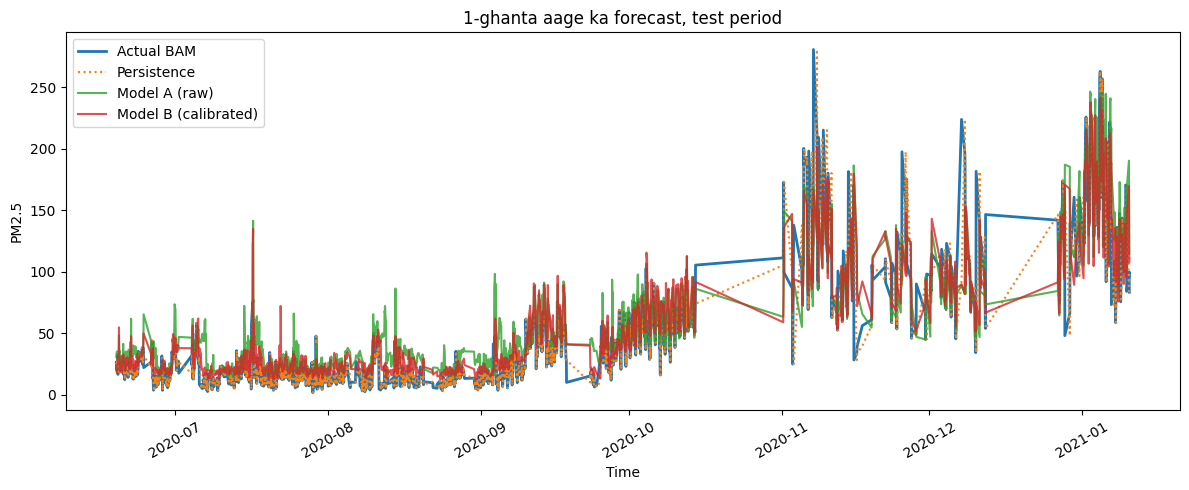

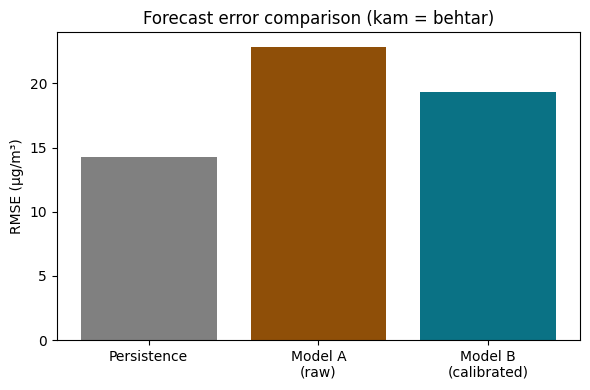

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(feat_test["time"], actual_test, label="Actual BAM", linewidth=2)
plt.plot(feat_test["time"], pred_persistence_test, label="Persistence", linestyle=":")
plt.plot(feat_test["time"], pred_A_test, label="Model A (raw)", alpha=0.8)
plt.plot(feat_test["time"], pred_B_test, label="Model B (calibrated)", alpha=0.8)
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.title(f"{HORIZON}-ghanta aage ka forecast, test period")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

labels = ["Persistence", "Model A\n(raw)", "Model B\n(calibrated)"]
rmses = [rmse_pers, rmse_A, rmse_B]
plt.figure(figsize=(6, 4))
plt.bar(labels, rmses, color=["gray", "#8F4F08", "#0A7285"])
plt.ylabel("RMSE (\u00b5g/m\u00b3)")
plt.title("Forecast error comparison (kam = behtar)")
plt.tight_layout()
plt.show()